In [1]:
import numpy
import pandas
import matplotlib
import seaborn
import sklearn
import xgboost

print("All packages imported successfully!")


All packages imported successfully!



Loading Tokyo dataset...

Dataset shape: (10958, 9)
   index  latitude  longitude valid_time  number        tp  band  spatial_ref  \
0      0     35.75     139.75 2011-01-01       0  0.011444     1            0   
1      1     35.75     139.75 2011-01-02       0  0.035286     1            0   
2      2     35.75     139.75 2011-01-03       0  0.188351     1            0   
3      3     35.75     139.75 2011-01-04       0  0.000000     1            0   
4      4     35.75     139.75 2011-01-05       0  0.000000     1            0   

   LCZ  
0  2.0  
1  2.0  
2  2.0  
3  2.0  
4  2.0  

--- Tokyo Rainfall Statistics ---
Mean rainfall: 4.034621
Median rainfall: 0.30899048
Std rainfall: 9.63003
Max rainfall: 201.59865


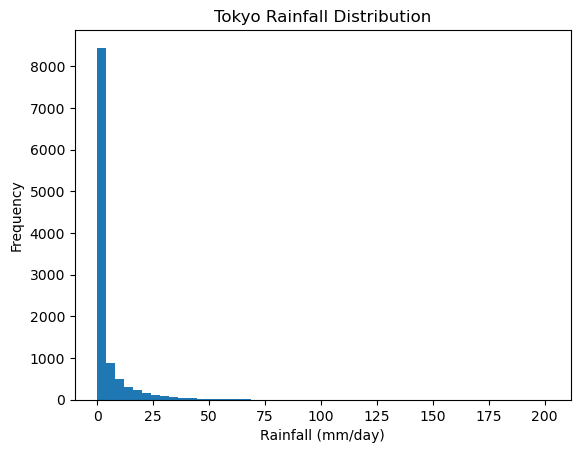


Extreme rainfall threshold (95th percentile): 21.218061447143555

Extreme rainfall counts:
extreme_rain
0    10410
1      548
Name: count, dtype: int64

--- Tokyo LCZ Distribution ---
LCZ
2.0    5479
3.0    5479
Name: count, dtype: int64


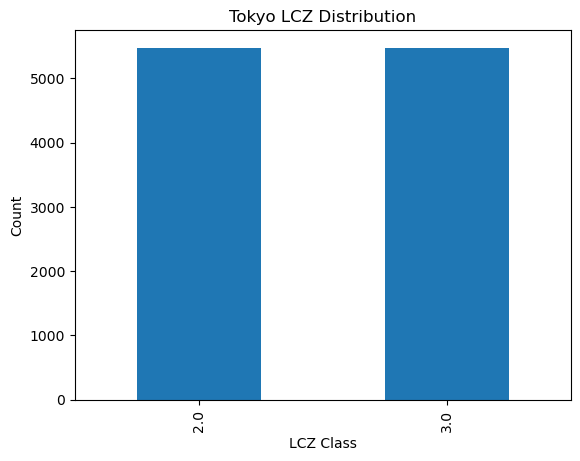


Week 6 dataset saved to: C:\Users\janaa\UrbanRainfall-ML-Thesis\Data\Processed\Tokyo_dataset_week6.csv


In [2]:
import xarray as xr
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# -----------------------------
# 1. LOAD DATASET
# -----------------------------

city_name = "Tokyo"

file_path = r"C:\Users\janaa\UrbanRainfall-ML-Thesis\Data\Processed\Tokyo_Combined_Flattened.nc"

print(f"\nLoading {city_name} dataset...")

ds = xr.open_dataset(file_path)

# convert to pandas dataframe
df = ds.to_dataframe().reset_index()

print(f"\nDataset shape: {df.shape}")
print(df.head())


# -----------------------------
# 2. RAINFALL DESCRIPTIVE STATISTICS
# -----------------------------

print(f"\n--- {city_name} Rainfall Statistics ---")

mean_rain = df["tp"].mean()
median_rain = df["tp"].median()
std_rain = df["tp"].std()
max_rain = df["tp"].max()

print("Mean rainfall:", mean_rain)
print("Median rainfall:", median_rain)
print("Std rainfall:", std_rain)
print("Max rainfall:", max_rain)


# -----------------------------
# 3. RAINFALL DISTRIBUTION
# -----------------------------

plt.figure()

plt.hist(df["tp"], bins=50)

plt.title(f"{city_name} Rainfall Distribution")
plt.xlabel("Rainfall (mm/day)")
plt.ylabel("Frequency")

plt.show()


# -----------------------------
# 4. EXTREME RAINFALL THRESHOLD
# -----------------------------

threshold = df["tp"].quantile(0.95)

print(f"\nExtreme rainfall threshold (95th percentile): {threshold}")


# -----------------------------
# 5. CREATE EXTREME RAIN LABEL
# -----------------------------

df["extreme_rain"] = (df["tp"] >= threshold).astype(int)

print("\nExtreme rainfall counts:")

print(df["extreme_rain"].value_counts())


# -----------------------------
# 6. LCZ DISTRIBUTION
# -----------------------------

print(f"\n--- {city_name} LCZ Distribution ---")

print(df["LCZ"].value_counts())

plt.figure()

df["LCZ"].value_counts().sort_index().plot(kind="bar")

plt.title(f"{city_name} LCZ Distribution")
plt.xlabel("LCZ Class")
plt.ylabel("Count")

plt.show()


# -----------------------------
# 7. SAVE WEEK 6 DATASET
# -----------------------------

output_file = fr"C:\Users\janaa\UrbanRainfall-ML-Thesis\Data\Processed\{city_name}_dataset_week6.csv"

df.to_csv(output_file, index=False)

print(f"\nWeek 6 dataset saved to: {output_file}")


Loaded Singapore dataset. Shape: (2663952, 7)

All dates are present!

Data snippet (first 5 pixels and first 5 days):
   pixel_id       date  rainfall   LCZ  extreme           x         y
0         0 2011-01-01  3.235750  17.0        0  103.514235  1.143841
1         1 2011-01-01       NaN  17.0        0  103.538149  1.143841
2         2 2011-01-01  2.360007  17.0        0  103.562062  1.143841
3         3 2011-01-01       NaN  17.0        0  103.585975  1.143841
4         4 2011-01-01  2.657351  17.0        0  103.609888  1.143841
5         5 2011-01-01       NaN  17.0        0  103.633801  1.143841
6         6 2011-01-01  2.560767  17.0        0  103.657714  1.143841
7         7 2011-01-01       NaN  17.0        0  103.681627  1.143841
8         8 2011-01-01  0.711433  17.0        0  103.705540  1.143841
9         9 2011-01-01       NaN  17.0        0  103.729453  1.143841

--- Singapore Rainfall Statistics ---
Mean rainfall: 7.389980427496648
Median rainfall: 4.58341695
Std rainfa

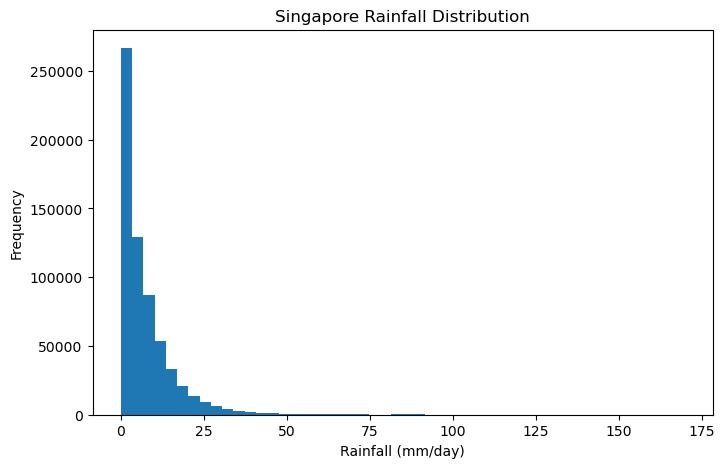


Extreme rainfall threshold (95th percentile): 23.67 mm/day

Extreme rainfall counts:
extreme
0    2632186
1      31766
Name: count, dtype: int64

Pixel date counts summary:
count     456.0
mean     5842.0
std         0.0
min      5842.0
25%      5842.0
50%      5842.0
75%      5842.0
max      5842.0
Name: date, dtype: float64

Pixels with incomplete time series (456):
pixel_id
0     5842
1     5842
2     5842
3     5842
4     5842
5     5842
6     5842
7     5842
8     5842
9     5842
10    5842
11    5842
12    5842
13    5842
14    5842
15    5842
16    5842
17    5842
18    5842
19    5842
Name: date, dtype: int64

--- Singapore LCZ Distribution ---
LCZ
17.0    1109980
4.0      368046
11.0     332994
12.0     286258
14.0     157734
3.0      140208
10.0      99314
9.0       75946
8.0       58420
13.0      17526
5.0        5842
7.0        5842
15.0       5842
Name: count, dtype: int64


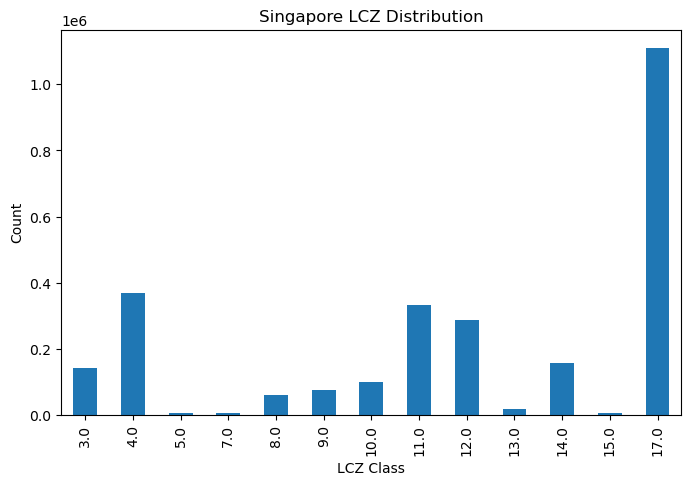

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# -----------------------------
# CONFIG
# -----------------------------
city_name = "Singapore"
csv_file = r"C:\Users\janaa\UrbanRainfall-ML-Thesis\Data\Processed\Singapore_ML_ready_with_coords.csv"

# -----------------------------
# 1. LOAD CSV
# -----------------------------
df = pd.read_csv(csv_file)
print(f"\nLoaded {city_name} dataset. Shape: {df.shape}")

# Make sure 'date' column is datetime
df['date'] = pd.to_datetime(df['date'], errors='coerce')

# -----------------------------
# 1b. CHECK ALL DATES
# -----------------------------
start_date = pd.Timestamp("2011-01-01")
end_date = pd.Timestamp("2025-12-31")

all_dates = pd.date_range(start=start_date, end=end_date, freq="D")
present_dates = df['date'].dropna().unique()
missing_dates = set(all_dates) - set(present_dates)

if missing_dates:
    print(f"\nMissing dates ({len(missing_dates)}):")
    print(sorted(list(missing_dates))[:20])
else:
    print("\nAll dates are present!")

# -----------------------------
# 1c. SHOW A SNIPPET
# -----------------------------
print("\nData snippet (first 5 pixels and first 5 days):")
print(df.head(10))  # show first 10 rows for context

# -----------------------------
# 2. RAINFALL DESCRIPTIVE STATISTICS
# -----------------------------
print(f"\n--- {city_name} Rainfall Statistics ---")
print("Mean rainfall:", df['rainfall'].mean())
print("Median rainfall:", df['rainfall'].median())
print("Std rainfall:", df['rainfall'].std())
print("Max rainfall:", df['rainfall'].max())

# -----------------------------
# 3. RAINFALL DISTRIBUTION
# -----------------------------
plt.figure(figsize=(8,5))
plt.hist(df['rainfall'].dropna(), bins=50)
plt.title(f"{city_name} Rainfall Distribution")
plt.xlabel("Rainfall (mm/day)")
plt.ylabel("Frequency")
plt.show()

# -----------------------------
# 4. EXTREME RAINFALL THRESHOLD
# -----------------------------
threshold = df['rainfall'].quantile(0.95)
print(f"\nExtreme rainfall threshold (95th percentile): {threshold:.2f} mm/day")

# -----------------------------
# 5. EXTREME RAIN LABEL COUNT
# -----------------------------
if 'extreme' in df.columns:
    print("\nExtreme rainfall counts:")
    print(df['extreme'].value_counts())
else:
    df['extreme'] = (df['rainfall'] >= threshold).astype(int)
    print("\nExtreme rainfall counts (computed):")
    print(df['extreme'].value_counts())

# -----------------------------
# 6. PIXEL TIME SERIES CHECK
# -----------------------------
pixel_counts = df.groupby('pixel_id')['date'].count()

print("\nPixel date counts summary:")
print(pixel_counts.describe())

# Optionally, show pixels with incomplete time series
expected_days = (end_date - start_date).days + 1
incomplete_pixels = pixel_counts[pixel_counts != expected_days]

if not incomplete_pixels.empty:
    print(f"\nPixels with incomplete time series ({len(incomplete_pixels)}):")
    print(incomplete_pixels.head(20))  # first 20 for inspection
else:
    print("\nAll pixels have complete time series!")
# 6. LCZ DISTRIBUTION
# -----------------------------
print(f"\n--- {city_name} LCZ Distribution ---")
print(df['LCZ'].value_counts())

plt.figure(figsize=(8,5))
df['LCZ'].value_counts().sort_index().plot(kind='bar')
plt.title(f"{city_name} LCZ Distribution")
plt.xlabel("LCZ Class")
plt.ylabel("Count")
plt.show()


Loaded London dataset. Shape: (3242310, 7)

All dates are present!

Data snippet (first 5 pixels and first 5 days):
   pixel_id       date  rainfall   LCZ  extreme         x          y
0         0 2011-01-01       0.0   NaN        0 -0.562903  51.312536
1         1 2011-01-01       NaN   NaN        0 -0.537903  51.312536
2         2 2011-01-01       0.0  12.0        0 -0.512903  51.312536
3         3 2011-01-01       NaN  12.0        0 -0.487903  51.312536
4         4 2011-01-01       0.0  11.0        0 -0.462903  51.312536
5         5 2011-01-01       NaN  14.0        0 -0.437903  51.312536
6         6 2011-01-01       0.0   6.0        0 -0.412903  51.312536
7         7 2011-01-01       NaN  12.0        0 -0.387903  51.312536
8         8 2011-01-01       0.0  12.0        0 -0.362903  51.312536
9         9 2011-01-01       NaN  11.0        0 -0.337903  51.312536

--- London Rainfall Statistics ---
Mean rainfall: 1.8982370691887793
Median rainfall: 0.25908925
Std rainfall: 3.9021669128

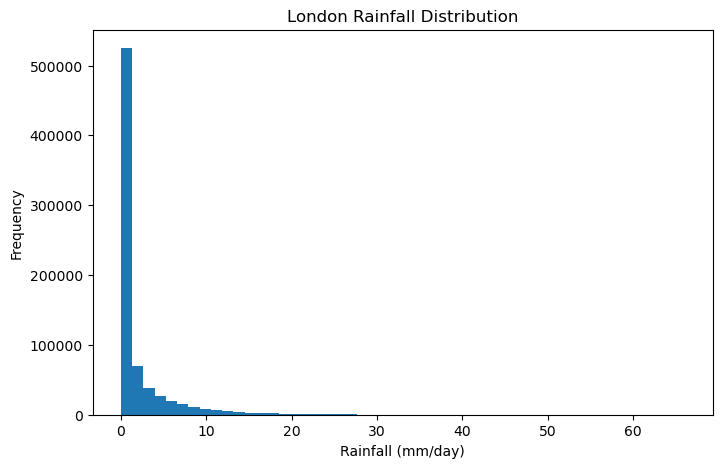


Extreme rainfall threshold (95th percentile): 9.63 mm/day

Extreme rainfall counts:
extreme
0    3205030
1      37280
Name: count, dtype: int64

--- London LCZ Distribution ---
LCZ
6.0     1256030
12.0     654304
14.0     286258
5.0      151892
8.0      134366
11.0     128524
17.0      35052
2.0       23368
3.0       17526
16.0       5842
Name: count, dtype: int64


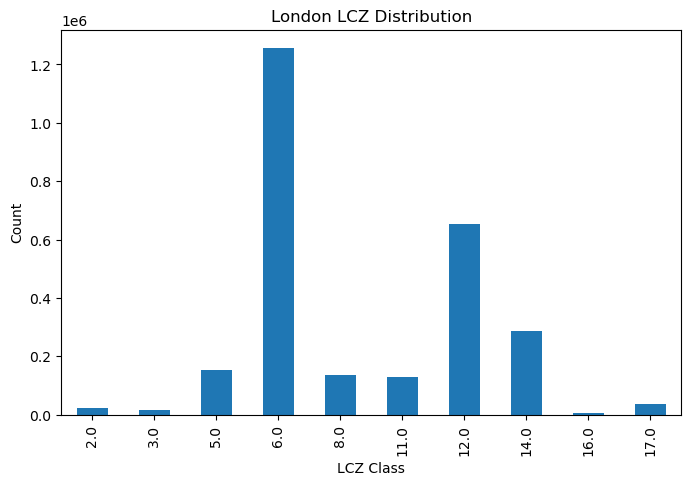

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# -----------------------------
# CONFIG
# -----------------------------
city_name = "London"
csv_file = r"C:\Users\janaa\UrbanRainfall-ML-Thesis\Data\Processed\London_ML_ready_with_coords.csv"

# -----------------------------
# 1. LOAD CSV
# -----------------------------
df = pd.read_csv(csv_file)
print(f"\nLoaded {city_name} dataset. Shape: {df.shape}")

# Make sure 'date' column is datetime
df['date'] = pd.to_datetime(df['date'], errors='coerce')

# -----------------------------
# 1b. CHECK ALL DATES
# -----------------------------
start_date = pd.Timestamp("2011-01-01")
end_date = pd.Timestamp("2025-12-31")

all_dates = pd.date_range(start=start_date, end=end_date, freq="D")
present_dates = df['date'].dropna().unique()
missing_dates = set(all_dates) - set(present_dates)

if missing_dates:
    print(f"\nMissing dates ({len(missing_dates)}):")
    print(sorted(list(missing_dates))[:20])
else:
    print("\nAll dates are present!")

# -----------------------------
# 1c. SHOW A SNIPPET
# -----------------------------
print("\nData snippet (first 5 pixels and first 5 days):")
print(df.head(10))  # show first 10 rows for context

# -----------------------------
# 2. RAINFALL DESCRIPTIVE STATISTICS
# -----------------------------
print(f"\n--- {city_name} Rainfall Statistics ---")
print("Mean rainfall:", df['rainfall'].mean())
print("Median rainfall:", df['rainfall'].median())
print("Std rainfall:", df['rainfall'].std())
print("Max rainfall:", df['rainfall'].max())

# -----------------------------
# 3. RAINFALL DISTRIBUTION
# -----------------------------
plt.figure(figsize=(8,5))
plt.hist(df['rainfall'].dropna(), bins=50)
plt.title(f"{city_name} Rainfall Distribution")
plt.xlabel("Rainfall (mm/day)")
plt.ylabel("Frequency")
plt.show()

# -----------------------------
# 4. EXTREME RAINFALL THRESHOLD
# -----------------------------
threshold = df['rainfall'].quantile(0.95)
print(f"\nExtreme rainfall threshold (95th percentile): {threshold:.2f} mm/day")

# -----------------------------
# 5. EXTREME RAIN LABEL COUNT
# -----------------------------
if 'extreme' in df.columns:
    print("\nExtreme rainfall counts:")
    print(df['extreme'].value_counts())
else:
    df['extreme'] = (df['rainfall'] >= threshold).astype(int)
    print("\nExtreme rainfall counts (computed):")
    print(df['extreme'].value_counts())

# -----------------------------
# 6. LCZ DISTRIBUTION
# -----------------------------
print(f"\n--- {city_name} LCZ Distribution ---")
print(df['LCZ'].value_counts())

plt.figure(figsize=(8,5))
df['LCZ'].value_counts().sort_index().plot(kind='bar')
plt.title(f"{city_name} LCZ Distribution")
plt.xlabel("LCZ Class")
plt.ylabel("Count")
plt.show()


Loaded newyork dataset. Shape: (2103120, 7)

All dates are present!

Data snippet (first 5 pixels and first 5 days):
   pixel_id       date  rainfall  LCZ  extreme          x        y
0         0 2011-01-01       NaN  6.0        0 -74.286957  40.5125
1         1 2011-01-01       0.0  0.0        0 -74.263043  40.5125
2         2 2011-01-01       NaN  6.0        0 -74.239130  40.5125
3         3 2011-01-01       0.0  6.0        0 -74.215217  40.5125
4         4 2011-01-01       NaN  6.0        0 -74.191304  40.5125
5         5 2011-01-01       0.0  0.0        0 -74.167391  40.5125
6         6 2011-01-01       NaN  0.0        0 -74.143478  40.5125
7         7 2011-01-01       0.0  0.0        0 -74.119565  40.5125
8         8 2011-01-01       NaN  0.0        0 -74.095652  40.5125
9         9 2011-01-01       0.0  0.0        0 -74.071739  40.5125

--- newyork Rainfall Statistics ---
Mean rainfall: 3.6641634329121504
Median rainfall: 0.168105175
Std rainfall: 8.589149762109773
Max rainfall:

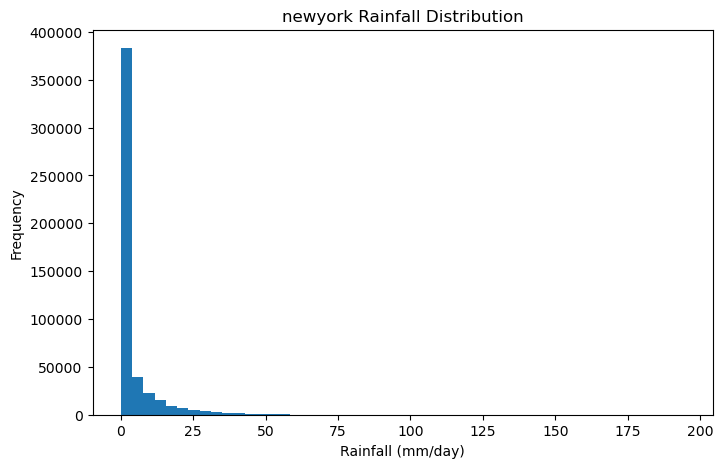


Extreme rainfall threshold (95th percentile): 19.90 mm/day

Extreme rainfall counts:
extreme
0    2078364
1      24756
Name: count, dtype: int64

--- newyork LCZ Distribution ---
LCZ
6.0     887984
0.0     473202
2.0     216154
17.0    122682
3.0     105156
12.0     93472
15.0     64262
4.0      52578
10.0     17526
5.0      17526
8.0      17526
14.0     11684
1.0      11684
11.0     11684
Name: count, dtype: int64


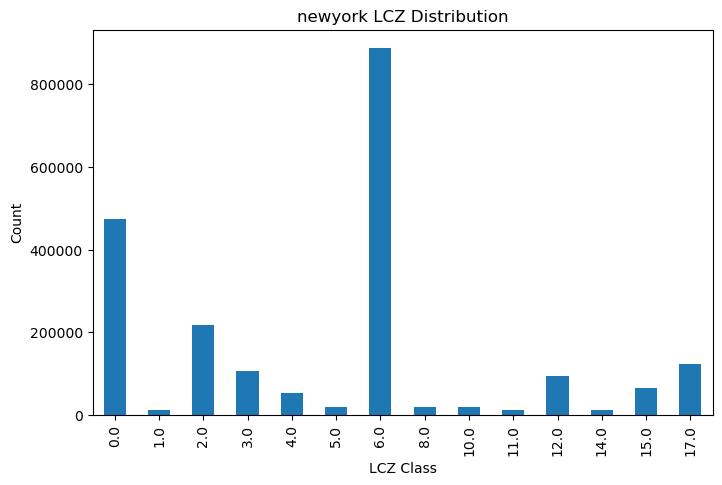

In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# -----------------------------
# CONFIG
# -----------------------------
city_name = "newyork"
csv_file = r"C:\Users\janaa\UrbanRainfall-ML-Thesis\Data\Processed\New_York_ML_ready_with_coords.csv"

# -----------------------------
# 1. LOAD CSV
# -----------------------------
df = pd.read_csv(csv_file)
print(f"\nLoaded {city_name} dataset. Shape: {df.shape}")

# Make sure 'date' column is datetime
df['date'] = pd.to_datetime(df['date'], errors='coerce')

# -----------------------------
# 1b. CHECK ALL DATES
# -----------------------------
start_date = pd.Timestamp("2011-01-01")
end_date = pd.Timestamp("2025-12-31")

all_dates = pd.date_range(start=start_date, end=end_date, freq="D")
present_dates = df['date'].dropna().unique()
missing_dates = set(all_dates) - set(present_dates)

if missing_dates:
    print(f"\nMissing dates ({len(missing_dates)}):")
    print(sorted(list(missing_dates))[:20])
else:
    print("\nAll dates are present!")

# -----------------------------
# 1c. SHOW A SNIPPET
# -----------------------------
print("\nData snippet (first 5 pixels and first 5 days):")
print(df.head(10))  # show first 10 rows for context

# -----------------------------
# 2. RAINFALL DESCRIPTIVE STATISTICS
# -----------------------------
print(f"\n--- {city_name} Rainfall Statistics ---")
print("Mean rainfall:", df['rainfall'].mean())
print("Median rainfall:", df['rainfall'].median())
print("Std rainfall:", df['rainfall'].std())
print("Max rainfall:", df['rainfall'].max())

# -----------------------------
# 3. RAINFALL DISTRIBUTION
# -----------------------------
plt.figure(figsize=(8,5))
plt.hist(df['rainfall'].dropna(), bins=50)
plt.title(f"{city_name} Rainfall Distribution")
plt.xlabel("Rainfall (mm/day)")
plt.ylabel("Frequency")
plt.show()

# -----------------------------
# 4. EXTREME RAINFALL THRESHOLD
# -----------------------------
threshold = df['rainfall'].quantile(0.95)
print(f"\nExtreme rainfall threshold (95th percentile): {threshold:.2f} mm/day")

# -----------------------------
# 5. EXTREME RAIN LABEL COUNT
# -----------------------------
if 'extreme' in df.columns:
    print("\nExtreme rainfall counts:")
    print(df['extreme'].value_counts())
else:
    df['extreme'] = (df['rainfall'] >= threshold).astype(int)
    print("\nExtreme rainfall counts (computed):")
    print(df['extreme'].value_counts())

# -----------------------------
# 6. LCZ DISTRIBUTION
# -----------------------------
print(f"\n--- {city_name} LCZ Distribution ---")
print(df['LCZ'].value_counts())

plt.figure(figsize=(8,5))
df['LCZ'].value_counts().sort_index().plot(kind='bar')
plt.title(f"{city_name} LCZ Distribution")
plt.xlabel("LCZ Class")
plt.ylabel("Count")
plt.show()


Loaded Tokyo dataset. Shape: (19570700, 7)

All dates are present!

Data snippet (first 5 pixels and first 5 days):
   pixel_id       date  rainfall   LCZ  extreme           x          y
0         0 2011-01-01       NaN   6.0        0  138.927976  35.033133
1         1 2011-01-01       NaN  11.0        0  138.952976  35.033133
2         2 2011-01-01       NaN  11.0        0  138.977976  35.033133
3         3 2011-01-01       NaN  11.0        0  139.002976  35.033133
4         4 2011-01-01       NaN  11.0        0  139.027976  35.033133
5         5 2011-01-01       NaN   6.0        0  139.052976  35.033133
6         6 2011-01-01       NaN  11.0        0  139.077976  35.033133
7         7 2011-01-01       NaN   0.0        0  139.102976  35.033133
8         8 2011-01-01       NaN   0.0        0  139.127976  35.033133
9         9 2011-01-01       NaN   0.0        0  139.152976  35.033133

--- Tokyo Rainfall Statistics ---
Mean rainfall: -547.5293884721511
Median rainfall: 0.25691726803779

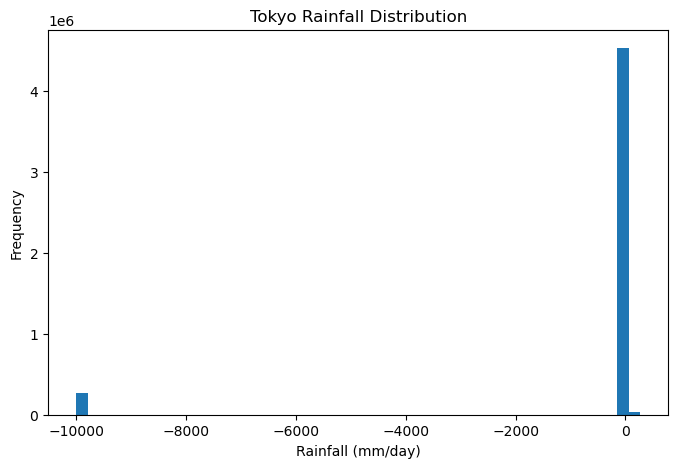


Extreme rainfall threshold (95th percentile): 22.94 mm/day

Extreme rainfall counts:
extreme
0    19329261
1      241439
Name: count, dtype: int64

--- Tokyo LCZ Distribution ---
LCZ
11.0    4685284
0.0     3960876
6.0     2488692
9.0     2056384
14.0    1641602
2.0     1086612
5.0     1051560
8.0      946404
12.0     525780
3.0      391414
17.0     356362
4.0      192786
10.0     110998
1.0       52578
15.0      23368
Name: count, dtype: int64


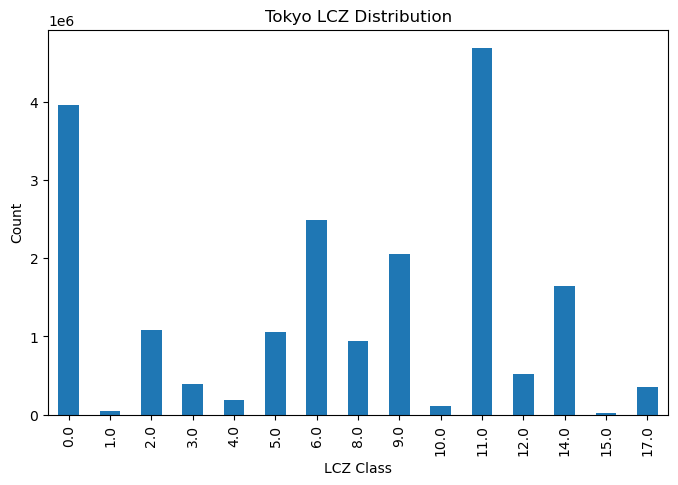

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# -----------------------------
# CONFIG
# -----------------------------
city_name = "Tokyo"
csv_file = r"C:\Users\janaa\UrbanRainfall-ML-Thesis\Data\Processed\Tokyo_ML_ready_with_coords.csv"

# -----------------------------
# 1. LOAD CSV
# -----------------------------
df = pd.read_csv(csv_file)
print(f"\nLoaded {city_name} dataset. Shape: {df.shape}")

# Make sure 'date' column is datetime
df['date'] = pd.to_datetime(df['date'], errors='coerce')

# -----------------------------
# 1b. CHECK ALL DATES
# -----------------------------
start_date = pd.Timestamp("2011-01-01")
end_date = pd.Timestamp("2025-12-31")

all_dates = pd.date_range(start=start_date, end=end_date, freq="D")
present_dates = df['date'].dropna().unique()
missing_dates = set(all_dates) - set(present_dates)

if missing_dates:
    print(f"\nMissing dates ({len(missing_dates)}):")
    print(sorted(list(missing_dates))[:20])
else:
    print("\nAll dates are present!")

# -----------------------------
# 1c. SHOW A SNIPPET
# -----------------------------
print("\nData snippet (first 5 pixels and first 5 days):")
print(df.head(10))  # show first 10 rows for context

# -----------------------------
# 2. RAINFALL DESCRIPTIVE STATISTICS
# -----------------------------
print(f"\n--- {city_name} Rainfall Statistics ---")
print("Mean rainfall:", df['rainfall'].mean())
print("Median rainfall:", df['rainfall'].median())
print("Std rainfall:", df['rainfall'].std())
print("Max rainfall:", df['rainfall'].max())

# -----------------------------
# 3. RAINFALL DISTRIBUTION
# -----------------------------
plt.figure(figsize=(8,5))
plt.hist(df['rainfall'].dropna(), bins=50)
plt.title(f"{city_name} Rainfall Distribution")
plt.xlabel("Rainfall (mm/day)")
plt.ylabel("Frequency")
plt.show()

# -----------------------------
# 4. EXTREME RAINFALL THRESHOLD
# -----------------------------
threshold = df['rainfall'].quantile(0.95)
print(f"\nExtreme rainfall threshold (95th percentile): {threshold:.2f} mm/day")

# -----------------------------
# 5. EXTREME RAIN LABEL COUNT
# -----------------------------
if 'extreme' in df.columns:
    print("\nExtreme rainfall counts:")
    print(df['extreme'].value_counts())
else:
    df['extreme'] = (df['rainfall'] >= threshold).astype(int)
    print("\nExtreme rainfall counts (computed):")
    print(df['extreme'].value_counts())

# -----------------------------
# 6. LCZ DISTRIBUTION
# -----------------------------
print(f"\n--- {city_name} LCZ Distribution ---")
print(df['LCZ'].value_counts())

plt.figure(figsize=(8,5))
df['LCZ'].value_counts().sort_index().plot(kind='bar')
plt.title(f"{city_name} LCZ Distribution")
plt.xlabel("LCZ Class")
plt.ylabel("Count")
plt.show()

In [9]:
import rioxarray as rxr
import numpy as np

lcz_files = {
    "Tokyo": r"C:\Users\janaa\UrbanRainfall-ML-Thesis\Data\Processed\Tokyo_LCZ.tif",
    "London": r"C:\Users\janaa\UrbanRainfall-ML-Thesis\Data\Processed\London_LCZ_degrees.tif",
    "New_York": r"C:\Users\janaa\UrbanRainfall-ML-Thesis\Data\Processed\New_York_LCZ.tif",
    "Singapore": r"C:\Users\janaa\UrbanRainfall-ML-Thesis\Data\Processed\SINGAPORE_LCZ.tif"
}

for city, path in lcz_files.items():
    lcz = rxr.open_rasterio(path, masked=True)
    # Take first band
    lcz_band = lcz.isel(band=0)
    # Compute average, ignoring masked/no-data
    avg = np.nanmean(lcz_band.data)
    print(f"{city} average LCZ class: {avg:.2f}")

Tokyo average LCZ class: 6.98
London average LCZ class: 8.68
New_York average LCZ class: 5.31
Singapore average LCZ class: 12.21


In [1]:
import pandas as pd

# Define the CSV file paths for all cities
cities = {
    "London": r"C:\Users\janaa\UrbanRainfall-ML-Thesis\Data\Processed\London_2011_2025_processed_nc.csv",
    "New_York": r"C:\Users\janaa\UrbanRainfall-ML-Thesis\Data\Processed\New_York_2011_2025_Combined_og_to_mm_nc.csv",
    "Singapore": r"C:\Users\janaa\UrbanRainfall-ML-Thesis\Data\Processed\Singapore_Combined_Sorted_og_to_mm_nc.csv",
    "Tokyo": r"C:\Users\janaa\UrbanRainfall-ML-Thesis\Data\Processed\Tokyo_Combined_og_to_mm_nc.csv"
}

# Function to check missing values
def check_missing_data(city, file_path):
    print(f"\n--- Checking data for {city} ---")
    df = pd.read_csv(file_path)

    # Check for missing values
    missing_data = df.isnull().sum()
    any_missing = missing_data.sum() > 0

    if any_missing:
        print("⚠️ Missing values detected:")
        for col, count in missing_data.items():
            if count > 0:
                print(f"  {col}: {count} missing")
    else:
        print("✅ No missing values found!")

    # Check for duplicate rows
    duplicate_rows = df.duplicated().sum()
    if duplicate_rows > 0:
        print(f"⚠️ {duplicate_rows} duplicate rows found")
    else:
        print("✅ No duplicate rows found")

    # Print shape and sample data
    print(f"Dataset shape: {df.shape}")
    print(f"Sample data:\n{df.head()}\n")

# Run the check for all cities
for city, file_path in cities.items():
    check_missing_data(city, file_path)


--- Checking data for London ---
✅ No missing values found!
✅ No duplicate rows found
Dataset shape: (21916, 5)
Sample data:
   pixel_id        date        tp  x_idx  y_idx
0         0  2011-01-01  1.093388      0      0
1         1  2011-01-01  1.057148      1      0
2         2  2011-01-01  1.054287      2      0
3         3  2011-01-01  0.846386      3      0
4         0  2011-01-02  0.009060      0      0


--- Checking data for New_York ---
✅ No missing values found!
✅ No duplicate rows found
Dataset shape: (32874, 5)
Sample data:
   valid_time  latitude  longitude        tp  number
0  2011-01-01     40.75     -74.25  0.000000       0
1  2011-01-01     40.75     -74.00  0.000000       0
2  2011-01-01     40.75     -73.75  0.000000       0
3  2011-01-01     40.50     -74.25  0.000000       0
4  2011-01-01     40.50     -74.00  0.000477       0


--- Checking data for Singapore ---
✅ No missing values found!
✅ No duplicate rows found
Dataset shape: (10958, 5)
Sample data:
   valid_

In [7]:
import pandas as pd

cities = {
    "London": r"C:\Users\janaa\UrbanRainfall-ML-Thesis\Data\Processed\London_2011_2025_processed_nc.csv",
    "New_York": r"C:\Users\janaa\UrbanRainfall-ML-Thesis\Data\Processed\New_York_2011_2025_Combined_og_to_mm_nc.csv",
    "Singapore": r"C:\Users\janaa\UrbanRainfall-ML-Thesis\Data\Processed\Singapore_Combined_Sorted_og_to_mm_nc.csv",
    "Tokyo": r"C:\Users\janaa\UrbanRainfall-ML-Thesis\Data\Processed\Tokyo_Combined_og_to_mm_nc.csv"
}

for city, path in cities.items():
    df = pd.read_csv(path)
    print(f"\n--- {city} ---")
    print(df.head(5))  # Show first 5 rows
    print(f"Columns: {df.columns.tolist()}")


--- London ---
   pixel_id        date        tp  x_idx  y_idx  avg_LCZ_city
0         0  2011-01-01  1.093388      0      0          8.68
1         1  2011-01-01  1.057148      1      0          8.68
2         2  2011-01-01  1.054287      2      0          8.68
3         3  2011-01-01  0.846386      3      0          8.68
4         0  2011-01-02  0.009060      0      0          8.68
Columns: ['pixel_id', 'date', 'tp', 'x_idx', 'y_idx', 'avg_LCZ_city']

--- New_York ---
   valid_time  latitude  longitude        tp  number  avg_LCZ_city
0  2011-01-01     40.75     -74.25  0.000000       0          5.31
1  2011-01-01     40.75     -74.00  0.000000       0          5.31
2  2011-01-01     40.75     -73.75  0.000000       0          5.31
3  2011-01-01     40.50     -74.25  0.000000       0          5.31
4  2011-01-01     40.50     -74.00  0.000477       0          5.31
Columns: ['valid_time', 'latitude', 'longitude', 'tp', 'number', 'avg_LCZ_city']

--- Singapore ---
   valid_time  latitud


--- Checking data for Tokyo ---
Loaded Tokyo dataset. Shape: (10958, 6)
✅ All dates are present!

Sample data (first 10 rows):
  valid_time  latitude  longitude        tp  number  avg_LCZ_city
0 2011-01-01     35.75     139.75  0.011444       0          6.98
1 2011-01-01     35.75     140.00  0.014305       0          6.98
2 2011-01-02     35.75     139.75  0.035286       0          6.98
3 2011-01-02     35.75     140.00  0.041008       0          6.98
4 2011-01-03     35.75     139.75  0.188351       0          6.98
5 2011-01-03     35.75     140.00  0.230312       0          6.98
6 2011-01-04     35.75     139.75  0.000000       0          6.98
7 2011-01-04     35.75     140.00  0.000000       0          6.98
8 2011-01-05     35.75     139.75  0.000000       0          6.98
9 2011-01-05     35.75     140.00  0.000000       0          6.98

--- Tokyo Rainfall Statistics ---
Mean rainfall: 4.034621020940275
Median rainfall: 0.30899048
Std rainfall: 9.630030027931703
Max rainfall: 201.

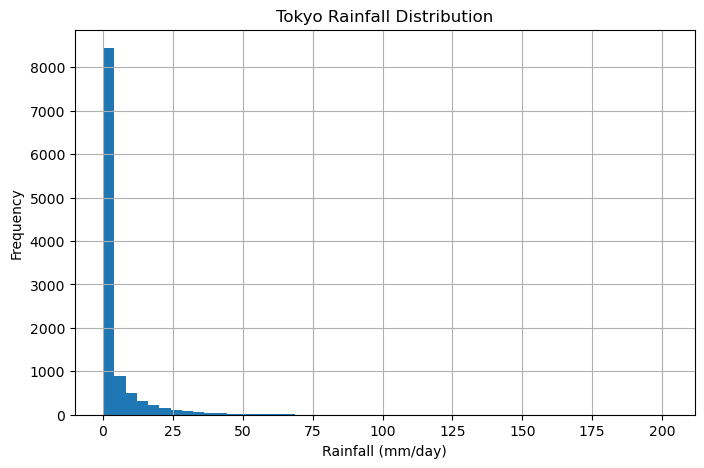


Extreme rainfall threshold (95th percentile): 21.22 mm/day

Extreme rainfall counts (computed):
extreme
0    10410
1      548
Name: count, dtype: int64
⚠️ No LCZ column found for Tokyo, skipping LCZ distribution.

--- Checking data for London ---
Loaded London dataset. Shape: (21916, 11)
✅ All dates are present!

Sample data (first 10 rows):
        date  latitude  longitude        tp  number  avg_LCZ_city  tavg  tmin  \
0 2011-01-01      51.5      -0.50  1.093388       1          8.68   5.6   4.1   
1 2011-01-01      51.5      -0.25  1.057148       1          8.68   5.6   4.1   
2 2011-01-01      51.5       0.00  1.054287       1          8.68   5.6   4.1   
3 2011-01-01      51.5       0.25  0.846386       0          8.68   5.6   4.1   
4 2011-01-02      51.5      -0.50  0.009060       0          8.68   2.9   2.1   
5 2011-01-02      51.5      -0.25  0.006676       0          8.68   2.9   2.1   
6 2011-01-02      51.5       0.00  0.004292       0          8.68   2.9   2.1   
7 2011-

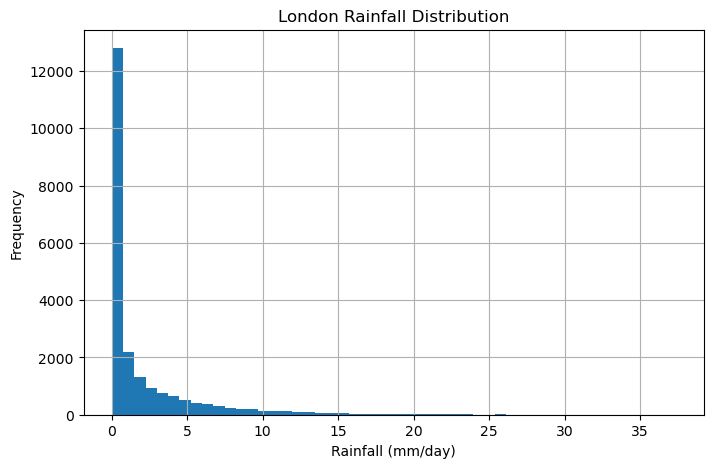


Extreme rainfall threshold (95th percentile): 9.34 mm/day

Extreme rainfall counts (computed):
extreme
0    20820
1     1096
Name: count, dtype: int64
⚠️ No LCZ column found for London, skipping LCZ distribution.

--- Checking data for New_York ---
Loaded New_York dataset. Shape: (32874, 6)
✅ All dates are present!

Sample data (first 10 rows):
  valid_time  latitude  longitude        tp  number  avg_LCZ_city
0 2011-01-01     40.75     -74.25  0.000000       0          5.31
1 2011-01-01     40.75     -74.00  0.000000       0          5.31
2 2011-01-01     40.75     -73.75  0.000000       0          5.31
3 2011-01-01     40.50     -74.25  0.000000       0          5.31
4 2011-01-01     40.50     -74.00  0.000477       0          5.31
5 2011-01-01     40.50     -73.75  0.001431       0          5.31
6 2011-01-02     40.75     -74.25  1.523972       0          5.31
7 2011-01-02     40.75     -74.00  1.665592       0          5.31
8 2011-01-02     40.75     -73.75  2.780438       0       

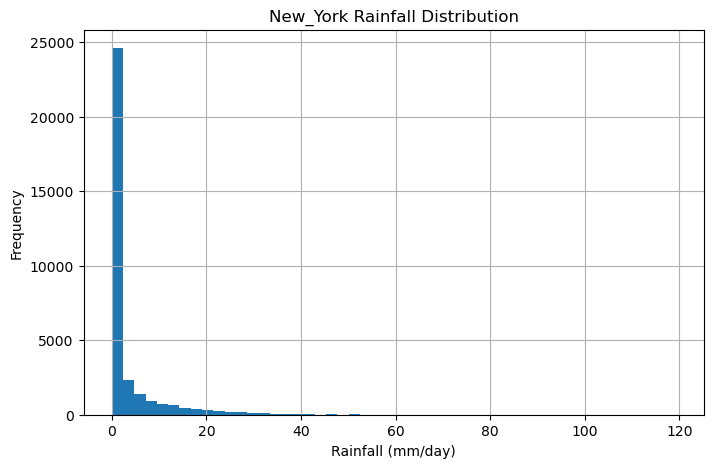


Extreme rainfall threshold (95th percentile): 17.52 mm/day

Extreme rainfall counts (computed):
extreme
0    31230
1     1644
Name: count, dtype: int64
⚠️ No LCZ column found for New_York, skipping LCZ distribution.

--- Checking data for Singapore ---
Loaded Singapore dataset. Shape: (10958, 6)
✅ All dates are present!

Sample data (first 10 rows):
  valid_time  latitude  longitude        tp  number  avg_LCZ_city
0 2011-01-01      1.25     103.75  2.213001       0         12.21
1 2011-01-01      1.25     104.00  3.792286       0         12.21
2 2011-01-02      1.25     103.75  5.237102       0         12.21
3 2011-01-02      1.25     104.00  5.456924       0         12.21
4 2011-01-03      1.25     103.75  4.998684       0         12.21
5 2011-01-03      1.25     104.00  4.050732       0         12.21
6 2011-01-04      1.25     103.75  0.326633       0         12.21
7 2011-01-04      1.25     104.00  0.232697       0         12.21
8 2011-01-05      1.25     103.75  0.420094       0  

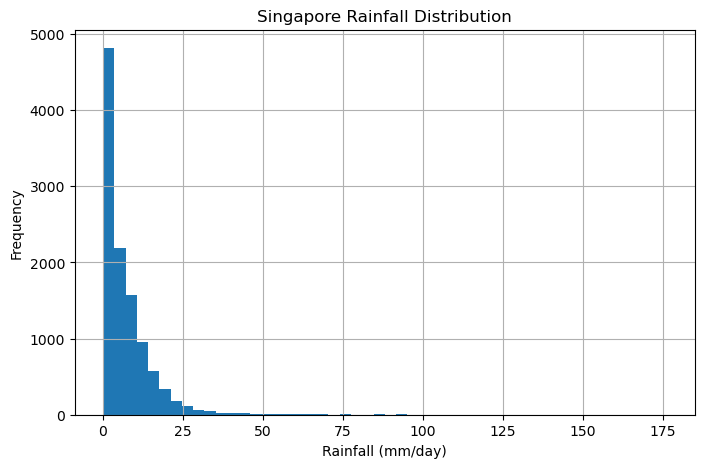


Extreme rainfall threshold (95th percentile): 20.83 mm/day

Extreme rainfall counts (computed):
extreme
0    10410
1      548
Name: count, dtype: int64
⚠️ No LCZ column found for Singapore, skipping LCZ distribution.


In [2]:
import pandas as pd
import matplotlib.pyplot as plt

# -----------------------------
# City info: CSV files and names
# -----------------------------
cities = {
    "Tokyo": r"C:\Users\janaa\UrbanRainfall-ML-Thesis\Data\Processed\Tokyo_Combined_og_to_mm_nc.csv",
    "London": r"C:\Users\janaa\UrbanRainfall-ML-Thesis\Data\Processed\London_final.csv",
    "New_York": r"C:\Users\janaa\UrbanRainfall-ML-Thesis\Data\Processed\New_York_2011_2025_Combined_og_to_mm_nc.csv",
    "Singapore": r"C:\Users\janaa\UrbanRainfall-ML-Thesis\Data\Processed\Singapore_Combined_Sorted_og_to_mm_nc.csv"
}

# -----------------------------
# Loop through each city
# -----------------------------
for city_name, csv_file in cities.items():
    print(f"\n--- Checking data for {city_name} ---")
    
    df = pd.read_csv(csv_file)
    print(f"Loaded {city_name} dataset. Shape: {df.shape}")
    
    # Make sure date column exists
    if 'date' in df.columns:
        df['date'] = pd.to_datetime(df['date'], errors='coerce')
        date_col = 'date'
    elif 'valid_time' in df.columns:
        df['valid_time'] = pd.to_datetime(df['valid_time'], errors='coerce')
        date_col = 'valid_time'
    else:
        print(f"⚠️ No date column found for {city_name}, skipping date check.")
        date_col = None
    
    # -----------------------------
    # Check missing dates
    # -----------------------------
    if date_col:
        start_date = pd.Timestamp("2011-01-01")
        end_date = pd.Timestamp("2025-12-31")
        all_dates = pd.date_range(start=start_date, end=end_date, freq="D")
        present_dates = df[date_col].dropna().unique()
        missing_dates = set(all_dates) - set(present_dates)
        if missing_dates:
            print(f"Missing dates ({len(missing_dates)}):")
            print(sorted(list(missing_dates))[:20])
        else:
            print("✅ All dates are present!")
    
    # -----------------------------
    # Snippet
    # -----------------------------
    print("\nSample data (first 10 rows):")
    print(df.head(10))
    
    # -----------------------------
    # Rainfall stats
    # -----------------------------
    if 'rainfall' in df.columns:
        rain_col = 'rainfall'
    elif 'tp' in df.columns:
        rain_col = 'tp'
    else:
        print(f"⚠️ No rainfall column found for {city_name}, skipping rainfall stats.")
        continue
    
    print(f"\n--- {city_name} Rainfall Statistics ---")
    print("Mean rainfall:", df[rain_col].mean())
    print("Median rainfall:", df[rain_col].median())
    print("Std rainfall:", df[rain_col].std())
    print("Max rainfall:", df[rain_col].max())
    
    # -----------------------------
    # Rainfall histogram
    # -----------------------------
    plt.figure(figsize=(8,5))
    df[rain_col].dropna().hist(bins=50)
    plt.title(f"{city_name} Rainfall Distribution")
    plt.xlabel("Rainfall (mm/day)")
    plt.ylabel("Frequency")
    plt.show()
    
    # -----------------------------
    # Extreme rainfall
    # -----------------------------
    threshold = df[rain_col].quantile(0.95)
    print(f"\nExtreme rainfall threshold (95th percentile): {threshold:.2f} mm/day")
    
    if 'extreme' in df.columns:
        print("\nExtreme rainfall counts:")
        print(df['extreme'].value_counts())
    else:
        df['extreme'] = (df[rain_col] >= threshold).astype(int)
        print("\nExtreme rainfall counts (computed):")
        print(df['extreme'].value_counts())
    
    # -----------------------------
    # LCZ distribution
    # -----------------------------
    if 'LCZ' in df.columns:
        print(f"\n--- {city_name} LCZ Distribution ---")
        print(df['LCZ'].value_counts())
        plt.figure(figsize=(8,5))
        df['LCZ'].value_counts().sort_index().plot(kind='bar')
        plt.title(f"{city_name} LCZ Distribution")
        plt.xlabel("LCZ Class")
        plt.ylabel("Count")
        plt.show()
    else:
        print(f"⚠️ No LCZ column found for {city_name}, skipping LCZ distribution.")

# Data Check Summary for All Cities

1. Tokyo

Dataset shape: 10,958 rows × 6 columns

Columns: valid_time, latitude, longitude, tp (total precipitation), number (pixel ID), avg_LCZ_city

All dates present from 2011-01-01 to 2025-12-31

## Rainfall statistics:

Mean: 4.03 mm/day

Median: 0.31 mm/day

Std: 9.63 mm/day

Max: 201.6 mm/day

Extreme rainfall threshold (95th percentile): 21.22 mm/day

Extreme rainfall counts:

Non-extreme: 10,410

Extreme: 548

LCZ distribution not available: Only avg_LCZ_city is present, no per-pixel LCZ.

2. London

Dataset shape: 21,916 rows × 6 columns

All dates present

Rainfall statistics: Mean 1.98 mm/day, Median 0.40 mm/day, Std 3.54 mm/day, Max 37.35 mm/day

Extreme rainfall threshold (95th percentile): 9.34 mm/day

Extreme rainfall counts: Non-extreme 20,820, Extreme 1,096

No per-pixel LCZ; only avg_LCZ_city = 8.68

3. New York

Dataset shape: 32,874 rows × 6 columns

All dates present

Rainfall statistics: Mean 3.06 mm/day, Median 0.12 mm/day, Std 6.92 mm/day, Max 119.16 mm/day

Extreme rainfall threshold (95th percentile): 17.52 mm/day

Extreme rainfall counts: Non-extreme 31,230, Extreme 1,644

No per-pixel LCZ; only avg_LCZ_city = 5.31

4. Singapore

Dataset shape: 10,958 rows × 6 columns

All dates present

Rainfall statistics: Mean 6.88 mm/day, Median 4.48 mm/day, Std 8.63 mm/day, Max 176.07 mm/day

Extreme rainfall threshold (95th percentile): 20.83 mm/day

Extreme rainfall counts: Non-extreme 10,410, Extreme 548

No per-pixel LCZ; only avg_LCZ_city = 12.21

### Key Observations

All datasets have complete daily coverage, no missing TP values.

Extreme rainfall labels are computed and ready for ML classification/regression tasks.

Per-pixel LCZ values are not included; only a city-wide avg_LCZ_city is available. If you want pixel-level LCZ as a feature, you would need to flatten the original LCZ rasters and merge.

The CSV structure is flattened and consistent across cities, which is suitable for ML input (features: latitude, longitude, tp, pixel number, avg_LCZ_city; target: extreme rainfall).

### ML Readiness

The data is ready for machine learning as-is for predicting extreme rainfall or total precipitation using pixel locations and city-average LCZ as a feature.

If desired, you can add additional features, like day-of-year, month, or merge original LCZ rasters for pixel-level urban type features.